In [1]:
# Importando as bibiotecas pandas e matplotlib.
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Lendo e transformando o arquivo csv em um dataFrame
df = pd.read_csv('googleplaystore.csv')
df

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


### 1. Remova as linhas duplicadas;

In [3]:
# Removendo linhas duplicadas
df = df.drop_duplicates()

### 2. Faça um gráfico de barras contendo os top 5 apps por número de instalação;
Para isso, vou verificar os dados da coluna "Installs".

In [ ]:
#Verificando os tipos de dados da coluna
df['Installs'].apply(type).value_counts()

Installs
<class 'str'>    10358
Name: count, dtype: int64

Verificado que a coluna "Installs" está como string. Sendo assim, vou transformá-la em numérica para poder fazer a contagem dos cinco aplicativos mais instalados.
Antes de transformar a coluna em numérica, preciso retirar os caracteres especiais dela.

In [ ]:
# Substituindo o + e , por um espaço
df['Installs'] = df['Installs'].str.replace(r'[\+,]', '', regex=True)

C:\Users\josim\AppData\Local\Temp\ipykernel_11608\286801902.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Installs'] = df['Installs'].str.replace(r'[\+,]', '', regex=True)


Ao tentar transformar a coluna "Install" em numérica, observei esse erro. (LINK DO ERRO FREE)
Para seguir com a transformação, vou remover a linha do "Free".

In [ ]:
# Mantendo só as linhas que não tem o "Free"
df = df[df['Installs'] != 'Free']
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,10000,Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,500000,Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,5000000,Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,50000000,Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,100000,Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [ ]:
#Transformando a coluna em numérica
df['Installs'] = pd.to_numeric(df['Installs'])

In [ ]:
# Verificando se a transformação ocorreu da forma correta
df['Installs'].apply(type).value_counts()

Installs
<class 'int'>    10357
Name: count, dtype: int64

Verificado que agora a coluna "Installs" é do tipo numérico.
Agora, vou ordenar o dataFrame pela coluna "Installs", em ordem descrescente, para verificar quais os cinco aplicativos mais instalados.

In [ ]:
# Ordenando o dataFrame em ordem decrescente
df_ordem = df.sort_values('Installs', ascending = False)

In [ ]:
# Selecionando apenas os cinco primeiros
top5 = df_ordem.head()
top5

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
341,Hangouts,COMMUNICATION,4.0,3419249,Varies with device,1000000000,Free,0,Everyone,Communication,"July 21, 2018",Varies with device,Varies with device
3928,YouTube,VIDEO_PLAYERS,4.3,25623548,Varies with device,1000000000,Free,0,Teen,Video Players & Editors,"August 2, 2018",Varies with device,Varies with device
451,Gmail,COMMUNICATION,4.3,4604483,Varies with device,1000000000,Free,0,Everyone,Communication,"August 2, 2018",Varies with device,Varies with device
3996,Google Chrome: Fast & Secure,COMMUNICATION,4.3,9642112,Varies with device,1000000000,Free,0,Everyone,Communication,"August 1, 2018",Varies with device,Varies with device
1700,Subway Surfers,GAME,4.5,27723193,76M,1000000000,Free,0,Everyone 10+,Arcade,"July 12, 2018",1.90.0,4.1 and up


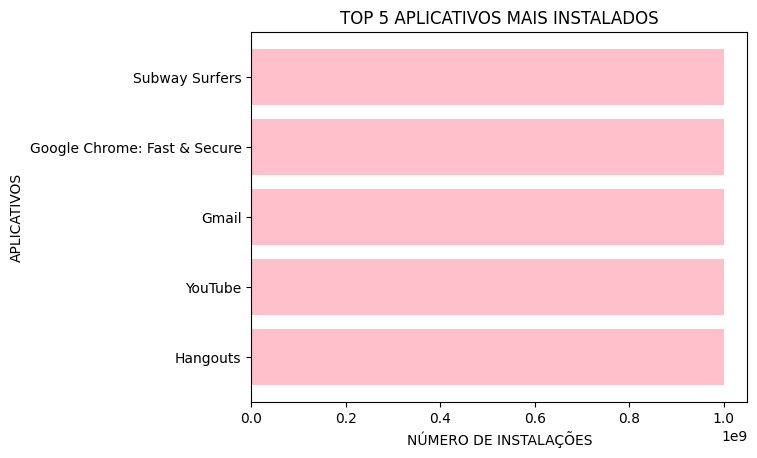

In [46]:
# Criando gráfico de barras horizontais na cor rosa
plt.barh(top5['App'], top5['Installs'], color='pink')

# Adicionando título e rótulo dos eixos
plt.title('TOP 5 APLICATIVOS MAIS INSTALADOS')
plt.xlabel('NÚMERO DE INSTALAÇÕES')
plt.ylabel('APLICATIVOS')

# Salvando a imagem do gráfico
plt.savefig('top5.png', bbox_inches='tight')
plt.show()

### 3. Faça um gráfico de pizza (pie chart) mostrando as categorias de apps existentes no dataset de acordo com a frequência em que elas aparecem;

Para a melhor visualização do gráfico, vou mostrar apenas as três categorias mais frequentes e as demais vou mostrar como "Outras".

In [4]:
# Contando os aplicativos por categoria e transformando em porcentagem
cont_categoria = df['Category'].value_counts(normalize=True) * 100
cont_categoria = cont_categoria.round(2)

# Selecionando as 10 categorias mais frequentes e fazendo a contagem das outras
top3 = cont_categoria.head(3)
outras = cont_categoria[3:].sum()

#Criando a categoria "Outras"
top3['OUTRAS'] = outras

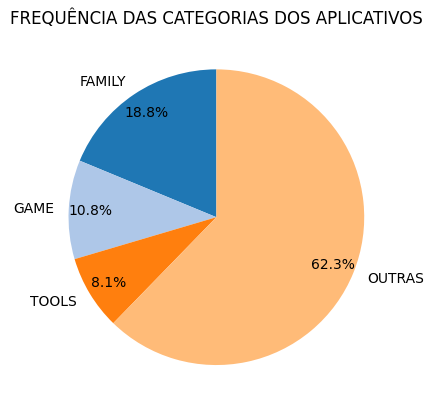

In [8]:
# Colocando cores diferentes
colors = plt.cm.tab20.colors

# Criando o gráfico pizza com as 10 categorias mais frequentes e outras
plt.pie(top3, labels=top3.index, autopct='%1.1f%%', startangle=90, pctdistance=0.85, labeldistance=1.1, colors=colors)

# Colocando um título para o gráfico
plt.title('FREQUÊNCIA DAS CATEGORIAS DOS APLICATIVOS')

# Salvando a imagem do gráfico
plt.savefig('categorias-pizza.png')

# Mostrando o gráfico
plt.show()

### 4. Mostre qual o app mais caro existente no dataset;

In [16]:
# Verificando o tipo de dado da coluna "Price"
df['Price'].apply(type).value_counts()

Price
<class 'str'>    10358
Name: count, dtype: int64

In [17]:
# Retirando símbolos e caracteres da coluna "Price"
df['Price'] = df['Price'].replace({'\$': '', ',': ''}, regex=True)

# Transformando a coluna em float
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

C:\Users\josim\AppData\Local\Temp\ipykernel_5384\1436372723.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Price'] = df['Price'].replace({'\$': '', ',': ''}, regex=True)
C:\Users\josim\AppData\Local\Temp\ipykernel_5384\1436372723.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Price'] = pd.to_numeric(df['Price'], errors='coerce')


In [34]:
# Descobrindo o aplicativo mais caro
caro = df.loc[df['Price'].idxmax()]

# Exibindo o resultado
resultado = f"O aplicativo mais caro é {caro['App']} e custa {caro['Price']} dólares."
print(resultado)

O aplicativo mais caro é I'm Rich - Trump Edition e custa 400.0 dólares.


### 5. Mostre quantos apps são classificados como "Mature 17+";

Vou selecionar apenas os aplicativos cujo a classificação seja "Mature 17+" e depois fazer a contagem.

In [54]:
# Selecionado os aplicativos que tenham "Mature 17+" na coluna "Content Rating"
mature = df[df['Content Rating'] == 'Mature 17+']

# Contando quantos aplicativos são
qnt_mature = mature.shape[0]

#Exibindo o resultado
print (f"O número de aplicativos classificados como 'Mature 17+' é {qnt_mature}.")


O número de aplicativos classificados como 'Mature 17+' é 447.


### 6. Mostre o top 10 apps por número de reviwes bem como o respectivo número de reviews. Ordene a lista de forma descrescente por número de reviews.

In [5]:
# Verificando o tipo de dado da coluna "Reviews"
df['Reviews'].apply(type).value_counts()

Reviews
<class 'str'>    10358
Name: count, dtype: int64

In [6]:
# Alterando o tipo da coluna de string para numérico
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')

C:\Users\josim\AppData\Local\Temp\ipykernel_4680\748617010.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')


In [10]:
# Ordenando os 10 aplicativos com mais reviews em ordem decresente
top10 = df[['App', 'Reviews']].sort_values('Reviews', ascending=False).head(10)
top10

,App,Reviews
2544,Facebook,78158306.0
3943,Facebook,78128208.0
336,WhatsApp Messenger,69119316.0
3904,WhatsApp Messenger,69109672.0
2604,Instagram,66577446.0
2545,Instagram,66577313.0
3909,Instagram,66509917.0
382,Messenger – Text and Video Chat for Free,56646578.0
335,Messenger – Text and Video Chat for Free,56642847.0
1879,Clash of Clans,44893888.0


Verifiquei que existem variações do mesmo aplicativo. Sendo assim, vou expor apenas a com maior número de reviews.

In [12]:
# Elminando as duplicidades mantendo a com maior número de reviews
rev_sem_duplicados = df.sort_values('Reviews', ascending=False).drop_duplicates(subset=['App'], keep='first')

In [ ]:
#Exibindo o resultado dos 10 aplicativo com mais reviews em ordem decrescente
top10 = rev_sem_duplicados[['App', 'Reviews']].head(10)
print(top10)

                                                    App     Reviews
2544                                           Facebook  78158306.0
336                                  WhatsApp Messenger  69119316.0
2604                                          Instagram  66577446.0
382            Messenger – Text and Video Chat for Free  56646578.0
1879                                     Clash of Clans  44893888.0
4005            Clean Master- Space Cleaner & Antivirus  42916526.0
1872                                     Subway Surfers  27725352.0
3665                                            YouTube  25655305.0
7536  Security Master - Antivirus, VPN, AppLock, Boo...  24900999.0
1878                                       Clash Royale  23136735.0


### 7. Crie pelo menos mais 2 cálculos sobre o dataset e apresente um em formato de lista e outro em formato de valor.

### - Quantos aplicativos tem "Beauty" como gênero?

In [ ]:
# Verificando o tipo da coluna "Genres"
df['Reviews'].apply(type).value_counts()

Reviews
<class 'float'>    10358
Name: count, dtype: int64

In [9]:
# Alterando o tipo da coluna "Genres" para string
genres_str = df['Genres'].astype(str)

# Procurando "Beauty" dentro da coluna "Genres", ignorando maiúsculas, minúsculas e nulos.
beauty= genres_str.str.contains("Beauty", case=False, na=False)

# Contando quantos aplicativos tem "Beauty" como gênero
beauty_count = beauty.sum()

print("A quantidade de aplicativos com o gênero 'Beauty' é ", beauty_count,".")

A quantidade de aplicativos com o gênero 'Beauty' é  53 .


### Qual o Top 5 dos aplicativos com gênero "Beauty" ordenados por avaliação?

In [4]:
# Verificando o tipo da coluna "Rating"
df['Reviews'].apply(type).value_counts()

Reviews
<class 'str'>    10358
Name: count, dtype: int64

In [6]:
# Alterando o tipo da coluna "Rating" e "Installs" (caso haja empate)
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce') 
df['Installs'] = (df['Installs'].astype(str).str.replace('[+,]', '', regex=True))
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')

C:\Users\josim\AppData\Local\Temp\ipykernel_3620\974045323.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
C:\Users\josim\AppData\Local\Temp\ipykernel_3620\974045323.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Installs'] = (df['Installs'].astype(str).str.replace('[+,]', '', regex=True))
C:\Users\josim\AppData\Local\Temp\ipykernel_3620\974045323.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Da

In [38]:
# Procurando apenas aplicativos com "Beauty" dentro da coluna "Genres", ignorando maiúsculas, minúsculas e nulos.
beauty= genres_str.str.contains("Beauty", case=False, na=False)

df_beauty = df[beauty]
top5 = df_beauty.sort_values(by=['Rating', 'Installs'], ascending=[False, False])[['App', 'Rating', 'Genres', 'Installs']].head(5).reset_index(drop=True)

print("TOP 5 APLICATIVOS DO GÊNERO BEAUTY POR CRITÉRIO DE AVALIAÇÃO")
print(top5)

TOP 5 APLICATIVOS DO GÊNERO BEAUTY POR CRITÉRIO DE AVALIAÇÃO
                               App  Rating  Genres   Installs
0   ipsy: Makeup, Beauty, and Tips     4.9  Beauty  1000000.0
1             Prom MakeUp Tutorial     4.8  Beauty    10000.0
2                      Ulta Beauty     4.7  Beauty  1000000.0
3       Hush - Beauty for Everyone     4.7  Beauty   500000.0
4  Natural recipes for your beauty     4.7  Beauty   100000.0


### 8. Crie pelo menos outras 2 formas gráficas de exibição dos indicadores acima utilizando a biblioteca Matplotlib;

Primeiro, vou fazer um gráfico "Donut" representando o top 5 aplicativos do gênero Beauty

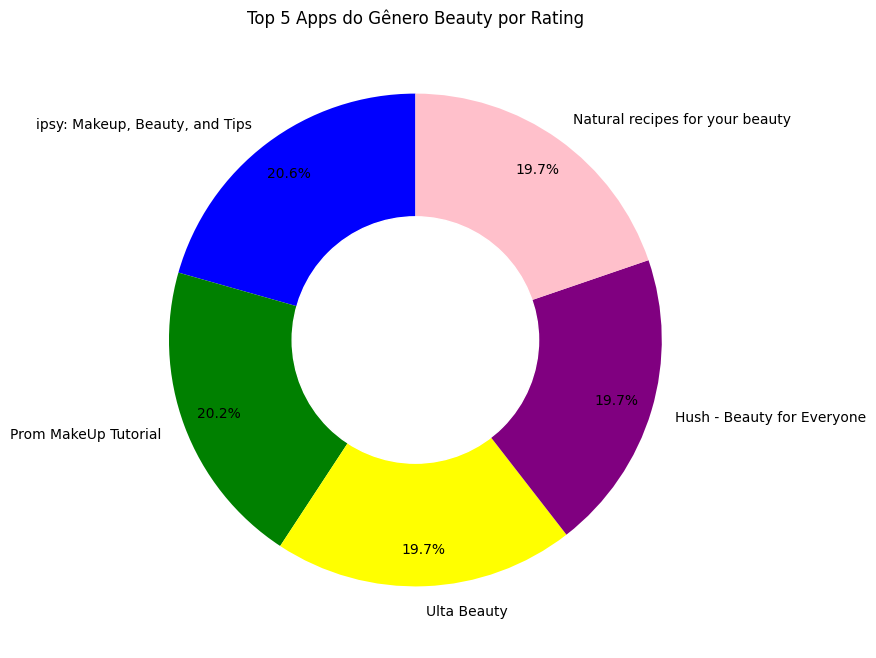

In [37]:
#Determinando o tamanho das fatias e colocando o nome dos aplicativos
sizes = top5['Rating'] 
labels = top5['App'] 

#Escolhendo as cores
cores = ['blue', 'green', 'yellow', 'purple', 'pink']

plt.figure(figsize=(12,8))
plt.pie(sizes, labels=labels, colors=cores, autopct='%1.1f%%', startangle=90, pctdistance=0.85)

# Desenhando o círculo no meio para virar donut
centro = plt.Circle((0,0), 0.50, color='white')
fig = plt.gcf()
fig.gca().add_artist(centro)

# Definindo o título e salvando a imagem do gráfico
plt.title('Top 5 Apps do Gênero Beauty por Rating')
plt.savefig('grafico-donut.png')
plt.show()



Agora, vou criar um gráfico mostrando os aplicativos com gênero "Beauty"

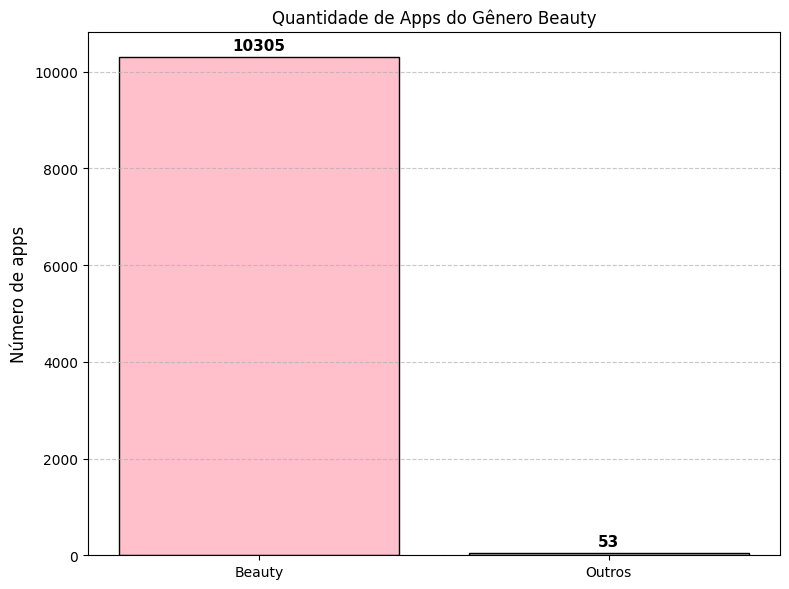

In [45]:

# Valores já calculados
qtd_beauty = beauty_count
qtd_outros = len(df) - beauty_count

# Rótulos e cores
valores = [qtd_outros, qtd_beauty]
labels = ['Beauty', 'Outros']
cores = ['pink', 'lightgray']

# Criando o gráfico
plt.figure(figsize=(8,6))
barras = plt.bar(labels, valores, color=cores, edgecolor='black')

# Adicionando valores no topo
plt.bar_label(barras, labels=[str(v) for v in valores], padding=3, fontsize=11, fontweight='bold')

plt.ylabel('Número de apps', fontsize=12)

# Adicionando título
plt.title('Quantidade de Apps do Gênero Beauty')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

#Salvando a imagem do gráfico
plt.savefig('grafico-barra-gen.png')
plt.show()